
===== PERFORMANCE =====
Final Capital: 10002.63
Cumulative Return: 0.03%
Sharpe Ratio: 0.71
Max Drawdown: 0.00%


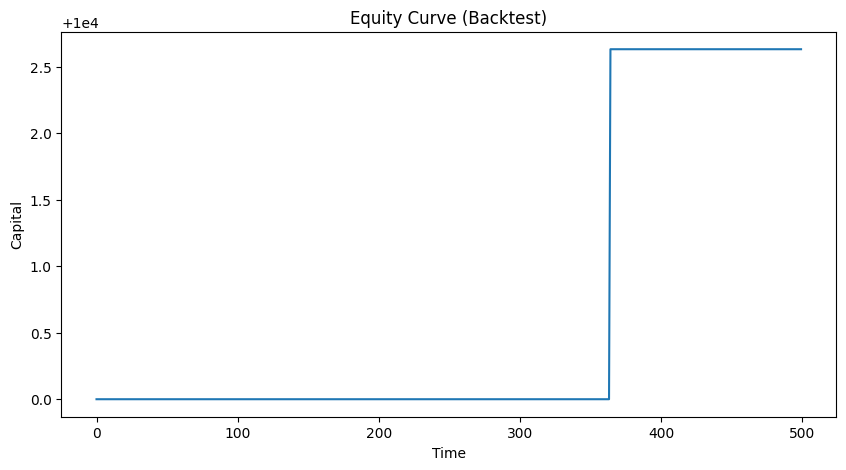

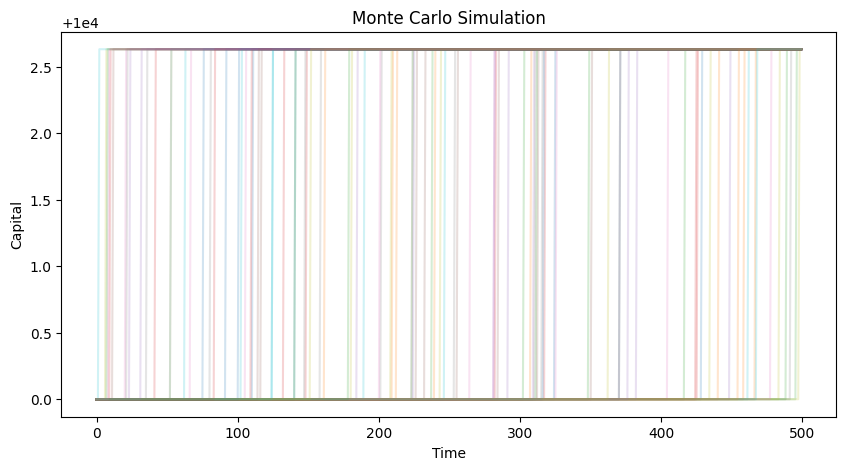

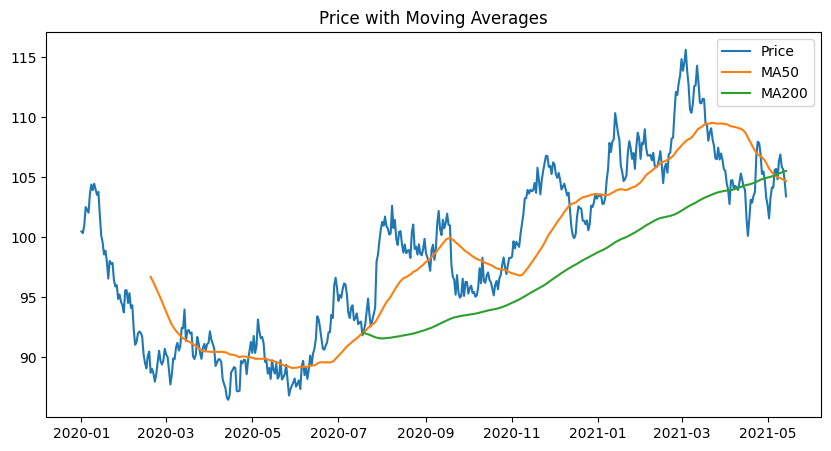

In [1]:
#Desiging & backtesting complex trading strategies

# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 2. GENERATE SYNTHETIC MARKET DATA
# ============================================

np.random.seed(42)

dates = pd.date_range(start="2020-01-01", periods=500)
price = 100 + np.cumsum(np.random.normal(0, 1, len(dates)))

df = pd.DataFrame({"Date": dates, "Close": price})
df.set_index("Date", inplace=True)

# ============================================
# 3. TECHNICAL INDICATORS
# ============================================

# Moving Averages
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

# RSI
delta = df["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df["RSI"] = 100 - (100 / (1 + rs))

# Bollinger Bands
df["MA20"] = df["Close"].rolling(20).mean()
df["STD"] = df["Close"].rolling(20).std()
df["Upper"] = df["MA20"] + 2 * df["STD"]
df["Lower"] = df["MA20"] - 2 * df["STD"]

# ============================================
# 4. STRATEGY (ENTRY & EXIT RULES)
# ============================================

df["Signal"] = 0

# Entry: Trend + RSI oversold + below lower band
df["Signal"] = np.where(
    (df["MA50"] > df["MA200"]) &
    (df["RSI"] < 30) &
    (df["Close"] < df["Lower"]),
    1, 0
)

# Exit: RSI overbought OR above upper band
df["Exit"] = np.where(
    (df["RSI"] > 70) |
    (df["Close"] > df["Upper"]),
    1, 0
)

# ============================================
# 5. BACKTEST ENGINE
# ============================================

initial_capital = 10000
capital = initial_capital
position = 0
entry_price = 0

equity_curve = []

risk_per_trade = 0.02
stop_loss_pct = 0.03
take_profit_pct = 0.06

for i in range(len(df)):

    price = df["Close"].iloc[i]

    # ENTRY
    if df["Signal"].iloc[i] == 1 and position == 0:
        position = capital * risk_per_trade / price
        entry_price = price
        stop_loss = price * (1 - stop_loss_pct)
        take_profit = price * (1 + take_profit_pct)

    # EXIT CONDITIONS
    elif position > 0:
        if price <= stop_loss:
            capital += (price - entry_price) * position
            position = 0

        elif price >= take_profit:
            capital += (price - entry_price) * position
            position = 0

        elif df["Exit"].iloc[i] == 1:
            capital += (price - entry_price) * position
            position = 0

    equity_curve.append(capital)

# ============================================
# 6. PERFORMANCE METRICS
# ============================================

equity_series = pd.Series(equity_curve)

returns = equity_series.pct_change().dropna()

sharpe = np.sqrt(252) * returns.mean() / returns.std()

cumulative_return = (equity_series.iloc[-1] / initial_capital) - 1

max_drawdown = np.max(
    (np.maximum.accumulate(equity_series) - equity_series) /
    np.maximum.accumulate(equity_series)
)

print("\n===== PERFORMANCE =====")
print(f"Final Capital: {capital:.2f}")
print(f"Cumulative Return: {cumulative_return*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown*100:.2f}%")

# ============================================
# 7. MONTE CARLO SIMULATION (ROBUSTNESS)
# ============================================

simulations = []

for _ in range(100):
    shuffled_returns = np.random.permutation(returns)
    sim_equity = [initial_capital]

    for r in shuffled_returns:
        sim_equity.append(sim_equity[-1] * (1 + r))

    simulations.append(sim_equity)

# ============================================
# 8. VISUALIZATION
# ============================================

# Equity Curve
plt.figure(figsize=(10,5))
plt.plot(equity_curve)
plt.title("Equity Curve (Backtest)")
plt.xlabel("Time")
plt.ylabel("Capital")
plt.show()

# Monte Carlo Paths
plt.figure(figsize=(10,5))
for sim in simulations:
    plt.plot(sim, alpha=0.2)

plt.title("Monte Carlo Simulation")
plt.xlabel("Time")
plt.ylabel("Capital")
plt.show()

# Price + Signals
plt.figure(figsize=(10,5))
plt.plot(df["Close"], label="Price")
plt.plot(df["MA50"], label="MA50")
plt.plot(df["MA200"], label="MA200")
plt.legend()
plt.title("Price with Moving Averages")
plt.show()


